In [1]:
import pandas as pd
import requests
import zipfile
import io

# IDEB 2023 — municípios
url_ideb = "https://download.inep.gov.br/ideb/resultados/divulgacao_municipios_ideb_2023.zip"

response = requests.get(url_ideb)
z = zipfile.ZipFile(io.BytesIO(response.content))
z.extractall("dados/ideb")

print("Arquivos baixados:")
print(z.namelist())

BadZipFile: File is not a zip file

In [2]:
print(response.status_code)
print(response.url)
print(response.content[:200])

404
https://download.inep.gov.br/ideb/resultados/divulgacao_municipios_ideb_2023.zip
b'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd">\r\n\r\n<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="pt-br" lang="pt-br"><h'


In [3]:
import pandas as pd

df_ai = pd.read_excel("dados/ideb/divulgacao_anos_iniciais_municipios_2023.xlsx")
df_af = pd.read_excel("dados/ideb/divulgacao_anos_finais_municipios_2023.xlsx")

print("Anos Iniciais:")
print(df_ai.shape)
print(df_ai.head(3))

Anos Iniciais:
(14523, 122)
                                   Unnamed: 0  \
0                                         NaN   
1                                         NaN   
2  Ensino Fundamental Regular - Anos Iniciais   

                              Ministério da Educação Unnamed: 2 Unnamed: 3  \
0  Instituto Nacional de Estudos e Pesquisas Educ...        NaN        NaN   
1                                                NaN        NaN        NaN   
2                                                NaN        NaN        NaN   

  Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ...  \
0        NaN        NaN        NaN        NaN        NaN        NaN  ...   
1        NaN        NaN        NaN        NaN        NaN        NaN  ...   
2        NaN        NaN        NaN        NaN        NaN        NaN  ...   

  Unnamed: 112 Unnamed: 113 Unnamed: 114 Unnamed: 115 Unnamed: 116  \
0          NaN          NaN          NaN          NaN          NaN   
1          NaN   

In [4]:
print(df_ai.head(10).to_string())

                                                                                                                                                                                                                                                                 Unnamed: 0                                                  Ministério da Educação             Unnamed: 2 Unnamed: 3                Unnamed: 4            Unnamed: 5           Unnamed: 6           Unnamed: 7           Unnamed: 8           Unnamed: 9                  Unnamed: 10               Unnamed: 11           Unnamed: 12          Unnamed: 13          Unnamed: 14          Unnamed: 15          Unnamed: 16                  Unnamed: 17               Unnamed: 18           Unnamed: 19          Unnamed: 20          Unnamed: 21          Unnamed: 22          Unnamed: 23                  Unnamed: 24               Unnamed: 25           Unnamed: 26          Unnamed: 27          Unnamed: 28          Unnamed: 29          Unnamed: 30            

In [6]:
df_ai = pd.read_excel(
    "dados/ideb/divulgacao_anos_iniciais_municipios_2023.xlsx",
    header=9  # linha 8 tem os nomes das colunas (contando do zero)
)

print(df_ai.shape)
print(df_ai.columns.tolist()[:10])  # primeiras 10 colunas
print(df_ai.head(2))

(14514, 122)
['SG_UF', 'CO_MUNICIPIO', 'NO_MUNICIPIO', 'REDE', 'VL_APROVACAO_2005_SI_4', 'VL_APROVACAO_2005_SI', 'VL_APROVACAO_2005_1', 'VL_APROVACAO_2005_2', 'VL_APROVACAO_2005_3', 'VL_APROVACAO_2005_4']
  SG_UF  CO_MUNICIPIO           NO_MUNICIPIO       REDE  \
0    RO     1100015.0  Alta Floresta D'Oeste   Estadual   
1    RO     1100015.0  Alta Floresta D'Oeste  Municipal   

  VL_APROVACAO_2005_SI_4 VL_APROVACAO_2005_SI VL_APROVACAO_2005_1  \
0                   77.2                    -                70.4   
1                      -                    -                   -   

  VL_APROVACAO_2005_2 VL_APROVACAO_2005_3 VL_APROVACAO_2005_4  ...  \
0                78.2                73.7                82.5  ...   
1                   -                   -                   -  ...   

  VL_OBSERVADO_2021 VL_OBSERVADO_2023 VL_PROJECAO_2007 VL_PROJECAO_2009  \
0               4.6               5.9              3.6              3.9   
1               4.8               5.1           

In [9]:
with open("colunas.txt", "w") as f:
    for i, col in enumerate(df_ai.columns.tolist()):
        f.write(f"{i} {col}\n")

print("salvo!")

salvo!


In [10]:
colunas_interesse = [
    'SG_UF',
    'CO_MUNICIPIO', 
    'NO_MUNICIPIO',
    'REDE',
    'VL_OBSERVADO_2023',      # IDEB 2023
    'VL_NOTA_MATEMATICA_2023', # Nota SAEB Matemática
    'VL_NOTA_PORTUGUES_2023',  # Nota SAEB Português
    'VL_NOTA_MEDIA_2023'       # Nota média padronizada
]

df_ai_limpo = df_ai[colunas_interesse].copy()
print(df_ai_limpo.shape)
print(df_ai_limpo.head(5))

(14514, 8)
  SG_UF  CO_MUNICIPIO           NO_MUNICIPIO       REDE VL_OBSERVADO_2023  \
0    RO     1100015.0  Alta Floresta D'Oeste   Estadual               5.9   
1    RO     1100015.0  Alta Floresta D'Oeste  Municipal               5.1   
2    RO     1100015.0  Alta Floresta D'Oeste    Pública               5.3   
3    RO     1100023.0              Ariquemes   Estadual               6.1   
4    RO     1100023.0              Ariquemes  Municipal               5.3   

  VL_NOTA_MATEMATICA_2023 VL_NOTA_PORTUGUES_2023 VL_NOTA_MEDIA_2023  
0                   244.1                 222.33           6.664813  
1                  205.06                 200.92           5.530502  
2                  211.45                 204.42           5.716085  
3                  227.86                 210.08           6.132162  
4                  213.93                 203.06           5.738686  


In [11]:
# Filtra só a rede pública (agregado municipal)
df_ai_pub = df_ai_limpo[df_ai_limpo['REDE'] == 'Pública'].copy()

print(df_ai_pub.shape)
print(f"Municípios únicos: {df_ai_pub['CO_MUNICIPIO'].nunique()}")

(5566, 8)
Municípios únicos: 5566


In [12]:
df_inse_raw = pd.read_excel("dados/inse/INSE_2023_municipios.xlsx")
print(df_inse_raw.shape)
print(df_inse_raw.head(10).to_string())

(125741, 19)
   NU_ANO_SAEB  CO_UF SG_UF     NO_UF  CO_MUNICIPIO               NO_MUNICIPIO  TP_TIPO_REDE  TP_LOCALIZACAO  TP_CAPITAL  QTD_ALUNOS_INSE  MEDIA_INSE  PC_NIVEL_1  PC_NIVEL_2  PC_NIVEL_3  PC_NIVEL_4  PC_NIVEL_5  PC_NIVEL_6  PC_NIVEL_7  PC_NIVEL_8
0         2023     11    RO  Rondônia       1100122                  Ji-Paraná             2               1           2             3258      5.0083        0.16        6.71       18.43       25.63       24.64       14.36        9.18        0.89
1         2023     11    RO  Rondônia       1101559              Teixeirópolis             0               2           2               19      4.8242        5.26         NaN       21.05       31.58       26.32       15.79         NaN         NaN
2         2023     11    RO  Rondônia       1100205                Porto Velho             3               1           1             3610      4.8843        0.57       11.59       20.00       26.07       20.78       12.87        7.11        1.02
3  

In [13]:
for i, col in enumerate(df_inse_raw.columns.tolist()):
    print(i, col)

0 NU_ANO_SAEB
1 CO_UF
2 SG_UF
3 NO_UF
4 CO_MUNICIPIO
5 NO_MUNICIPIO
6 TP_TIPO_REDE
7 TP_LOCALIZACAO
8 TP_CAPITAL
9 QTD_ALUNOS_INSE
10 MEDIA_INSE
11 PC_NIVEL_1
12 PC_NIVEL_2
13 PC_NIVEL_3
14 PC_NIVEL_4
15 PC_NIVEL_5
16 PC_NIVEL_6
17 PC_NIVEL_7
18 PC_NIVEL_8


In [14]:
print(df_inse_raw['TP_TIPO_REDE'].value_counts())

TP_TIPO_REDE
3    49721
2    30786
0    14465
6    14465
5    14456
1      958
4      890
Name: count, dtype: int64


In [15]:
print(df_inse_raw.groupby('TP_TIPO_REDE')['NO_MUNICIPIO'].count())
print("---")
# Vamos ver um exemplo de cada tipo
for tipo in sorted(df_inse_raw['TP_TIPO_REDE'].unique()):
    exemplo = df_inse_raw[df_inse_raw['TP_TIPO_REDE'] == tipo].iloc[0]
    print(f"Tipo {tipo}: {exemplo['NO_MUNICIPIO']} | alunos: {exemplo['QTD_ALUNOS_INSE']}")

TP_TIPO_REDE
0    14465
1      958
2    30786
3    49721
4      890
5    14456
6    14465
Name: NO_MUNICIPIO, dtype: int64
---
Tipo 0: Teixeirópolis | alunos: 19
Tipo 1: Jaru | alunos: 54
Tipo 2: Ji-Paraná | alunos: 3258
Tipo 3: Porto Velho | alunos: 3610
Tipo 4: Cacoal | alunos: 389
Tipo 5: Governador Jorge Teixeira | alunos: 46
Tipo 6: Colorado do Oeste | alunos: 673


In [17]:
porto_velho = df_inse_raw[df_inse_raw['NO_MUNICIPIO'] == 'Porto Velho']
print(porto_velho[['TP_TIPO_REDE', 'TP_LOCALIZACAO', 'QTD_ALUNOS_INSE', 'MEDIA_INSE']].drop_duplicates('TP_TIPO_REDE').sort_values('TP_TIPO_REDE').to_string())

     TP_TIPO_REDE  TP_LOCALIZACAO  QTD_ALUNOS_INSE  MEDIA_INSE
116             0               1            13282      5.0087
363             1               1              131      5.2116
4               2               1             9541      5.0505
2               3               1             3610      4.8843
375             4               2              129         NaN
410             5               1            13151      5.0050
710             6               1            13282      5.0087


In [18]:
# Filtra tipo 6 (pública total) e seleciona colunas relevantes
df_inse_pub = df_inse_raw[df_inse_raw['TP_TIPO_REDE'] == 6][
    ['CO_MUNICIPIO', 'NO_MUNICIPIO', 'SG_UF', 'QTD_ALUNOS_INSE', 'MEDIA_INSE']
].copy()

print(df_inse_pub.shape)
print(f"Municípios únicos: {df_inse_pub['CO_MUNICIPIO'].nunique()}")
print(df_inse_pub.head(5))

(14465, 5)
Municípios únicos: 5558
    CO_MUNICIPIO       NO_MUNICIPIO SG_UF  QTD_ALUNOS_INSE  MEDIA_INSE
8        1100064  Colorado do Oeste    RO              673      5.0888
13       1101401        Monte Negro    RO              295      4.8648
15       1100403       Alto Paraíso    RO              386      4.8229
43       1101104    Itapuã do Oeste    RO              370      4.7245
45       1101609          Theobroma    RO              244      4.7415


In [19]:
# Quantas vezes cada município aparece?
contagem = df_inse_pub['CO_MUNICIPIO'].value_counts()
print(contagem.value_counts())

count
3    3349
2    2209
Name: count, dtype: int64


In [20]:
# Pega um município que aparece 3 vezes e vê as diferenças
exemplo = df_inse_pub[df_inse_pub['CO_MUNICIPIO'] == 1100064]
print(exemplo)

     CO_MUNICIPIO       NO_MUNICIPIO SG_UF  QTD_ALUNOS_INSE  MEDIA_INSE
8         1100064  Colorado do Oeste    RO              673      5.0888
673       1100064  Colorado do Oeste    RO              461      5.0446
883       1100064  Colorado do Oeste    RO              212      5.1788


In [21]:
# Busca as mesmas linhas no dataframe original pra ver o TP_LOCALIZACAO
# df_inse_raw é o dataframe original com todas as colunas
# .loc[exemplo.index] seleciona as linhas pelos índices que encontramos (8, 673, 883)
# exemplo.index são os índices das linhas que aparecem no resultado acima

exemplo_completo = df_inse_raw.loc[
    df_inse_raw[(df_inse_raw['CO_MUNICIPIO'] == 1100064) & 
                (df_inse_raw['TP_TIPO_REDE'] == 6)].index
][['CO_MUNICIPIO', 'NO_MUNICIPIO', 'TP_LOCALIZACAO', 'QTD_ALUNOS_INSE', 'MEDIA_INSE']]

print(exemplo_completo)

     CO_MUNICIPIO       NO_MUNICIPIO  TP_LOCALIZACAO  QTD_ALUNOS_INSE  \
8         1100064  Colorado do Oeste               0              673   
673       1100064  Colorado do Oeste               1              461   
883       1100064  Colorado do Oeste               2              212   

     MEDIA_INSE  
8        5.0888  
673      5.0446  
883      5.1788  


In [23]:
# df_inse_raw — dataframe original com todas as colunas
# TP_TIPO_REDE == 6 — pública total
# TP_LOCALIZACAO == 0 — total (urbano + rural)
# & — as duas condições precisam ser verdadeiras ao mesmo tempo
# [['colunas']] — seleciona só as que precisamos
# .copy() — cria uma cópia independente do dataframe original

df_inse_pub = df_inse_raw[
    (df_inse_raw['TP_TIPO_REDE'] == 6) & 
    (df_inse_raw['TP_LOCALIZACAO'] == 0)
][['CO_MUNICIPIO', 'NO_MUNICIPIO', 'SG_UF', 'QTD_ALUNOS_INSE', 'MEDIA_INSE']].copy()

print(df_inse_pub.shape)
print(f"Municípios únicos: {df_inse_pub['CO_MUNICIPIO'].nunique()}")

(5558, 5)
Municípios únicos: 5558


In [24]:
# pd.merge() — função que cruza dois dataframes
# df_ai_pub — dataframe do IDEB (anos iniciais, rede pública)
# df_inse_pub — dataframe do INSE (rede pública, total)
# on='CO_MUNICIPIO' — coluna usada pra identificar qual linha de um corresponde a qual linha do outro
# how='inner' — mantém só os municípios que existem nos DOIS dataframes
#               se um município está só no IDEB ou só no INSE, é descartado

df = pd.merge(df_ai_pub, df_inse_pub, on='CO_MUNICIPIO', how='inner')

print(df.shape)
print(f"Municípios no cruzamento: {df['CO_MUNICIPIO'].nunique()}")
print(df.head(3))

(5554, 12)
Municípios no cruzamento: 5554
  SG_UF_x  CO_MUNICIPIO         NO_MUNICIPIO_x     REDE VL_OBSERVADO_2023  \
0      RO     1100015.0  Alta Floresta D'Oeste  Pública               5.3   
1      RO     1100023.0              Ariquemes  Pública               5.4   
2      RO     1100031.0                 Cabixi  Pública               5.8   

  VL_NOTA_MATEMATICA_2023 VL_NOTA_PORTUGUES_2023 VL_NOTA_MEDIA_2023  \
0                  211.45                 204.42           5.716085   
1                  215.77                 203.99            5.79071   
2                  226.78                 206.52           6.046824   

          NO_MUNICIPIO_y SG_UF_y  QTD_ALUNOS_INSE  MEDIA_INSE  
0  Alta Floresta D'Oeste      RO              761      4.9904  
1              Ariquemes      RO             3130      4.9264  
2                 Cabixi      RO              180      4.9473  


In [25]:
# Renomeia e limpa colunas duplicadas
# .drop() — remove colunas que não precisamos mais
# columns=[...] — lista das colunas a remover
# .rename() — renomeia colunas
# columns={'nome_atual': 'nome_novo'} — dicionário de renomeações

df = df.drop(columns=['SG_UF_y', 'NO_MUNICIPIO_y', 'REDE'])
df = df.rename(columns={
    'SG_UF_x': 'SG_UF',
    'NO_MUNICIPIO_x': 'NO_MUNICIPIO'
})

print(df.columns.tolist())
print(df.shape)

['SG_UF', 'CO_MUNICIPIO', 'NO_MUNICIPIO', 'VL_OBSERVADO_2023', 'VL_NOTA_MATEMATICA_2023', 'VL_NOTA_PORTUGUES_2023', 'VL_NOTA_MEDIA_2023', 'QTD_ALUNOS_INSE', 'MEDIA_INSE']
(5554, 9)


In [26]:
# .dtypes — mostra o tipo de cada coluna
# object = texto, float64 = número decimal, int64 = número inteiro
# importante pra saber se alguma coluna numérica foi lida como texto

print(df.dtypes)
print("---")

# .isna().sum() — conta quantos valores ausentes (NaN) tem em cada coluna
# isna() retorna True/False pra cada célula
# .sum() soma os True (que valem 1) — resultado é o total de ausentes por coluna

print(df.isna().sum())

SG_UF                       object
CO_MUNICIPIO               float64
NO_MUNICIPIO                object
VL_OBSERVADO_2023           object
VL_NOTA_MATEMATICA_2023     object
VL_NOTA_PORTUGUES_2023      object
VL_NOTA_MEDIA_2023          object
QTD_ALUNOS_INSE              int64
MEDIA_INSE                 float64
dtype: object
---
SG_UF                      0
CO_MUNICIPIO               0
NO_MUNICIPIO               0
VL_OBSERVADO_2023          0
VL_NOTA_MATEMATICA_2023    0
VL_NOTA_PORTUGUES_2023     0
VL_NOTA_MEDIA_2023         0
QTD_ALUNOS_INSE            0
MEDIA_INSE                 0
dtype: int64


In [27]:
# Lista das colunas que precisam ser numéricas
# todas as que vieram do IDEB estão como texto

colunas_numericas = [
    'VL_OBSERVADO_2023',
    'VL_NOTA_MATEMATICA_2023', 
    'VL_NOTA_PORTUGUES_2023',
    'VL_NOTA_MEDIA_2023'
]

# pd.to_numeric() — converte uma coluna pra número
# errors='coerce' — qualquer valor que não conseguir converter (como '-')
#                   vira NaN em vez de dar erro
# o loop for aplica isso pra cada coluna da lista

for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verifica quantos NaN apareceram depois da conversão
print(df.isna().sum())
print("---")
print(df.dtypes)

SG_UF                        0
CO_MUNICIPIO                 0
NO_MUNICIPIO                 0
VL_OBSERVADO_2023          125
VL_NOTA_MATEMATICA_2023    124
VL_NOTA_PORTUGUES_2023     124
VL_NOTA_MEDIA_2023         124
QTD_ALUNOS_INSE              0
MEDIA_INSE                   0
dtype: int64
---
SG_UF                       object
CO_MUNICIPIO               float64
NO_MUNICIPIO                object
VL_OBSERVADO_2023          float64
VL_NOTA_MATEMATICA_2023    float64
VL_NOTA_PORTUGUES_2023     float64
VL_NOTA_MEDIA_2023         float64
QTD_ALUNOS_INSE              int64
MEDIA_INSE                 float64
dtype: object


In [28]:
# Remove municípios sem IDEB 2023
# .dropna() — remove linhas que têm NaN
# subset=['VL_OBSERVADO_2023'] — só verifica essa coluna específica
# sem o subset, removeria qualquer linha com NaN em qualquer coluna

df_limpo = df.dropna(subset=['VL_OBSERVADO_2023']).copy()

# Remove municípios com menos de 30 alunos no INSE
# amostras muito pequenas geram médias não confiáveis
# 30 é um limiar estatístico clássico — abaixo disso a média é instável

df_limpo = df_limpo[df_limpo['QTD_ALUNOS_INSE'] >= 30].copy()

print(f"Municípios antes: {len(df)}")
print(f"Municípios depois: {len(df_limpo)}")
print(f"Removidos sem IDEB: 125")
print(f"Removidos por amostra pequena: {len(df) - 125 - len(df_limpo)}")

Municípios antes: 5554
Municípios depois: 5416
Removidos sem IDEB: 125
Removidos por amostra pequena: 13


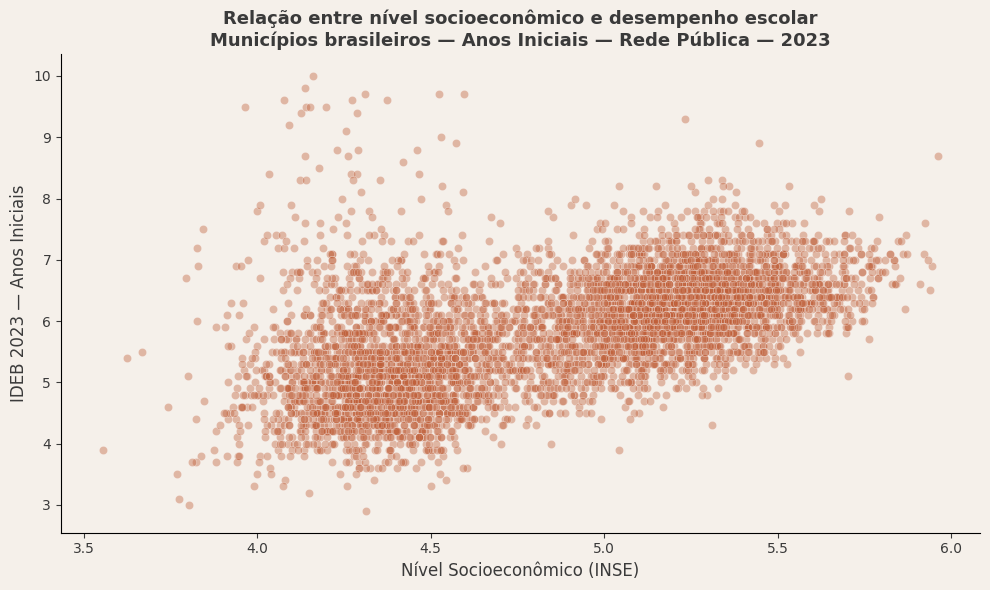

salvo!


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define as cores do Vértice
COR_PRINCIPAL = '#C0603A'  # terracota
COR_GRAFITE = '#3A3A3A'    # grafite pra textos
COR_CREME = '#F5F0EA'      # creme pra fundo

# Define o estilo geral da figura
# plt.rcParams — dicionário de configurações globais do matplotlib
# qualquer gráfico feito depois vai herdar essas configurações

plt.rcParams['axes.facecolor'] = COR_CREME
plt.rcParams['figure.facecolor'] = COR_CREME
plt.rcParams['text.color'] = COR_GRAFITE
plt.rcParams['axes.labelcolor'] = COR_GRAFITE
plt.rcParams['xtick.color'] = COR_GRAFITE
plt.rcParams['ytick.color'] = COR_GRAFITE

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_limpo,
    x='MEDIA_INSE',
    y='VL_OBSERVADO_2023',
    color=COR_PRINCIPAL,  # cor dos pontos
    alpha=0.4,
    ax=ax
)

# Remove bordas desnecessárias — visual mais limpo
# spine = cada um dos 4 lados do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Nível Socioeconômico (INSE)', fontsize=12)
ax.set_ylabel('IDEB 2023 — Anos Iniciais', fontsize=12)
ax.set_title(
    'Relação entre nível socioeconômico e desempenho escolar\n'
    'Municípios brasileiros — Anos Iniciais — Rede Pública — 2023',
    fontsize=13,
    fontweight='bold',
    color=COR_GRAFITE
)

plt.tight_layout()
plt.savefig('grafico_ideb_inse.png', dpi=150, bbox_inches='tight')
plt.show()

print("salvo!")

In [30]:
import urllib.request
import zipfile
import os

url = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2023/Brasil/BR/BR_Municipios_2023.zip"

urllib.request.urlretrieve(url, "dados/shapefiles/BR_Municipios_2023.zip")

with zipfile.ZipFile("dados/shapefiles/BR_Municipios_2023.zip", 'r') as z:
    z.extractall("dados/shapefiles/")

print("Shapefile baixado!")

HTTPError: HTTP Error 404: Not Found

In [31]:
url = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2023/Brasil/BR/BR_Municipios_2023_gpkg.zip"

urllib.request.urlretrieve(url, "dados/shapefiles/BR_Municipios_2023.zip")

with zipfile.ZipFile("dados/shapefiles/BR_Municipios_2023.zip", 'r') as z:
    z.extractall("dados/shapefiles/")

print("Shapefile baixado!")

HTTPError: HTTP Error 404: Not Found

In [32]:
import geopandas as gpd

gdf = gpd.read_file("dados/shapefiles/BR_Municipios_2024.shp")
print(gdf.shape)
print(gdf.columns.tolist())
print(gdf.head(2))

(5573, 16)
['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIA', 'NM_REGIA', 'SIGLA_RG', 'CD_CONCU', 'NM_CONCU', 'AREA_KM2', 'geometry']
    CD_MUN        NM_MUN  CD_RGI                NM_RGI CD_RGINT  \
0  2504108  Carrapateira  250015            Cajazeiras     2504   
1  1718451        Pugmil  170003  Paraíso do Tocantins     1701   

             NM_RGINT CD_UF      NM_UF SIGLA_UF CD_REGIA  NM_REGIA SIGLA_RG  \
0  Sousa - Cajazeiras    25    Paraíba       PB        2  Nordeste       NE   
1              Palmas    17  Tocantins       TO        1     Norte        N   

  CD_CONCU NM_CONCU  AREA_KM2  \
0     None     None    59.070   
1     None     None   401.174   

                                            geometry  
0  POLYGON ((-38.33672 -6.99279, -38.33653 -6.993...  
1  POLYGON ((-48.91085 -10.53824, -48.911 -10.538...  


In [33]:
# Verifica tipos e primeiros valores
print("shapefile:", gdf['CD_MUN'].dtype, gdf['CD_MUN'].head(3).tolist())
print("df_limpo:", df_limpo['CO_MUNICIPIO'].dtype, df_limpo['CO_MUNICIPIO'].head(3).tolist())

shapefile: object ['2504108', '1718451', '2104206']
df_limpo: float64 [1100015.0, 1100023.0, 1100031.0]


In [34]:
# Converte CO_MUNICIPIO para string sem decimal
df_limpo['CD_MUN'] = df_limpo['CO_MUNICIPIO'].astype(int).astype(str)

# Merge
gdf_ideb = gdf.merge(df_limpo, on='CD_MUN', how='left')

print(gdf_ideb.shape)
print(gdf_ideb['VL_OBSERVADO_2023'].isna().sum(), "municípios sem IDEB")

(5573, 25)
157 municípios sem IDEB


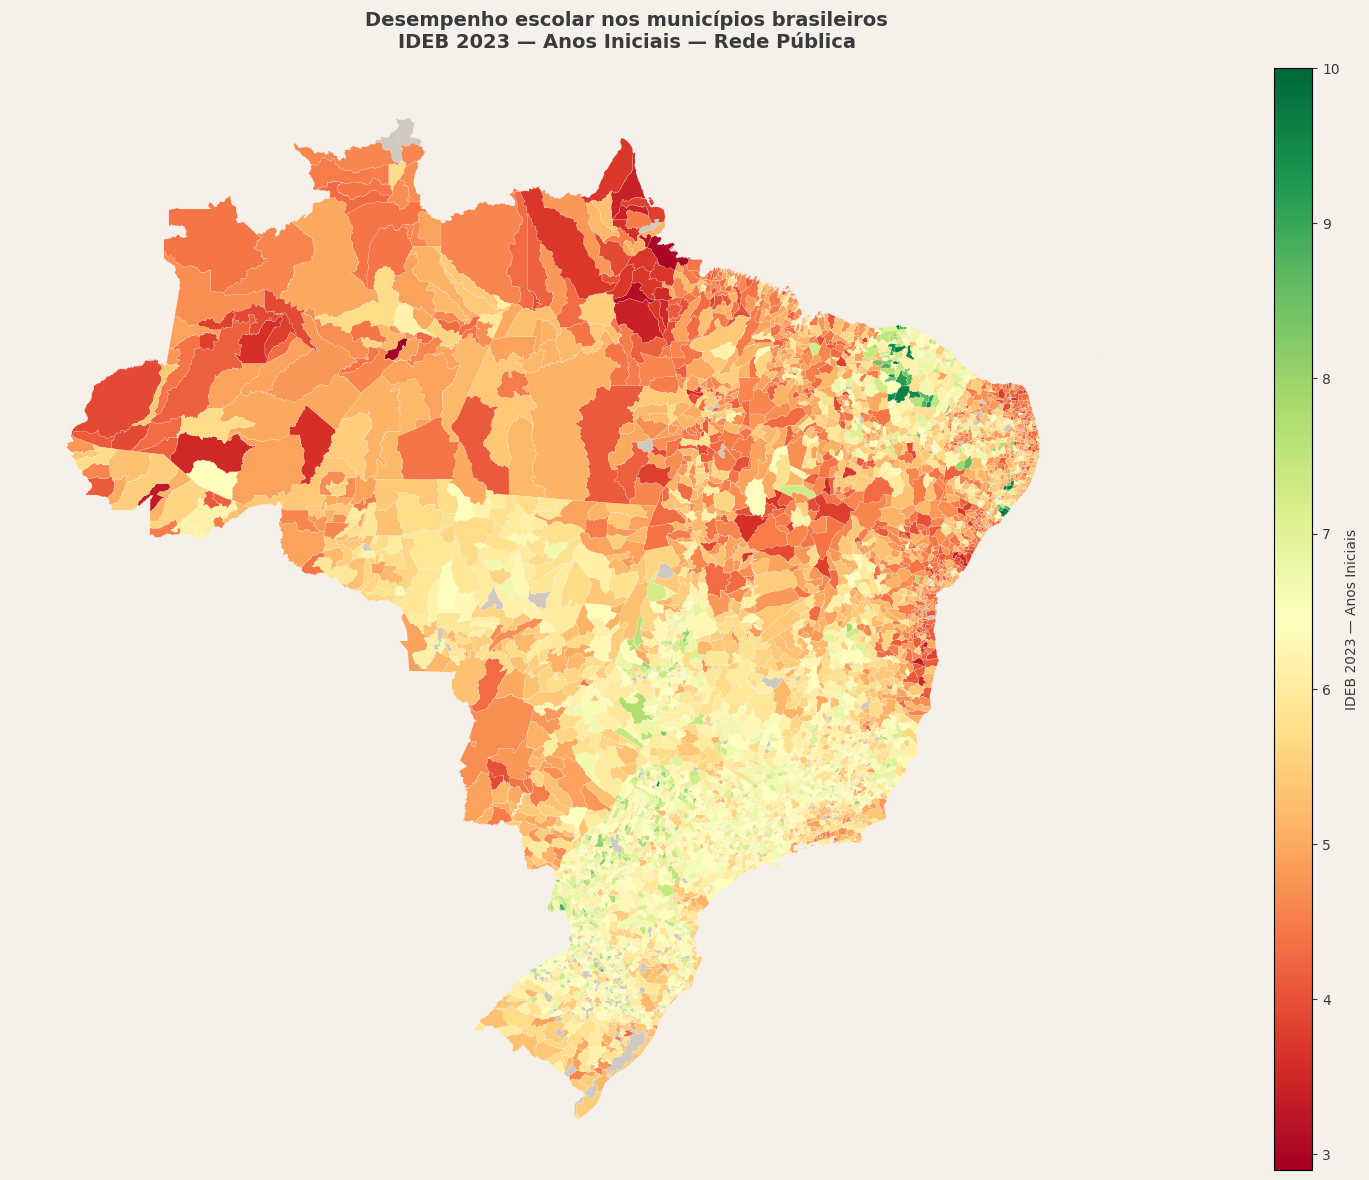

In [35]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

COR_FUNDO = '#F5F0EA'
COR_SEM_DADO = '#D0C9BF'

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(COR_FUNDO)
ax.set_facecolor(COR_FUNDO)

# Municípios sem dado
gdf_ideb[gdf_ideb['VL_OBSERVADO_2023'].isna()].plot(
    ax=ax, color=COR_SEM_DADO, linewidth=0.1
)

# Municípios com dado
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

gdf_ideb[gdf_ideb['VL_OBSERVADO_2023'].notna()].plot(
    column='VL_OBSERVADO_2023',
    ax=ax,
    cax=cax,
    cmap='RdYlGn',
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'IDEB 2023 — Anos Iniciais'}
)

ax.set_title(
    'Desempenho escolar nos municípios brasileiros\nIDEB 2023 — Anos Iniciais — Rede Pública',
    fontsize=14, fontweight='bold', color='#3A3A3A', pad=15
)
ax.axis('off')

plt.tight_layout()
plt.savefig('mapa_ideb_municipios.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
print(df_limpo['VL_OBSERVADO_2023'].describe())

count    5416.000000
mean        5.821436
std         0.928190
min         2.900000
25%         5.100000
50%         5.900000
75%         6.500000
max        10.000000
Name: VL_OBSERVADO_2023, dtype: float64


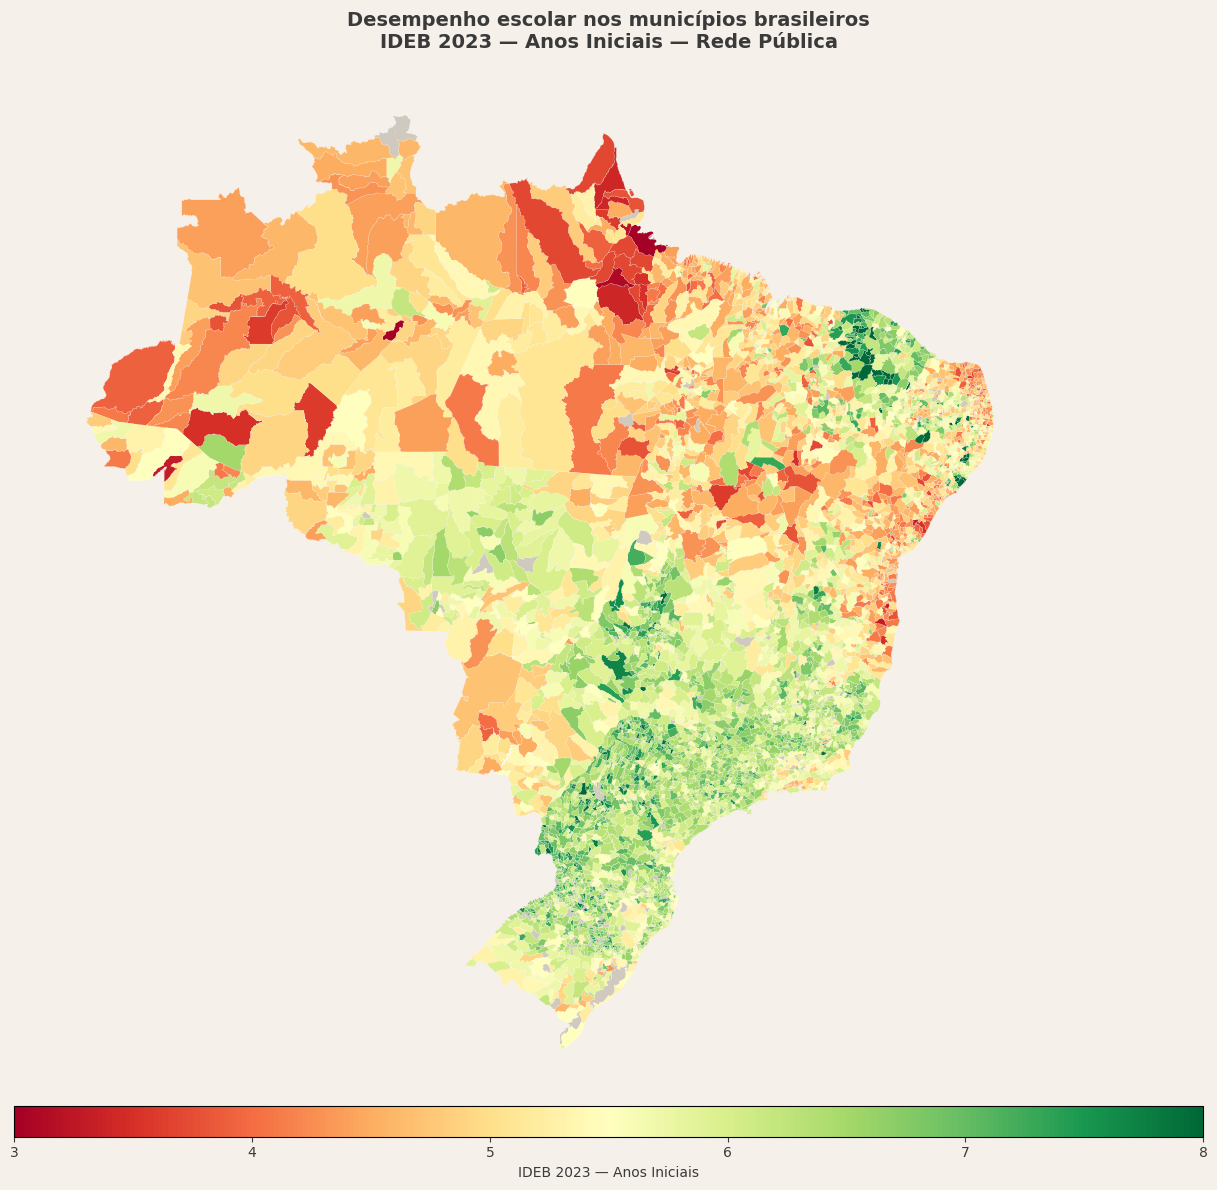

In [37]:
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(COR_FUNDO)
ax.set_facecolor(COR_FUNDO)

# Municípios sem dado
gdf_ideb[gdf_ideb['VL_OBSERVADO_2023'].isna()].plot(
    ax=ax, color=COR_SEM_DADO, linewidth=0.1
)

# Municípios com dado
divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

gdf_ideb[gdf_ideb['VL_OBSERVADO_2023'].notna()].plot(
    column='VL_OBSERVADO_2023',
    ax=ax,
    cax=cax,
    cmap='RdYlGn',
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    vmin=3, vmax=8,
    legend_kwds={
        'label': 'IDEB 2023 — Anos Iniciais',
        'orientation': 'horizontal'
    }
)

ax.set_title(
    'Desempenho escolar nos municípios brasileiros\nIDEB 2023 — Anos Iniciais — Rede Pública',
    fontsize=14, fontweight='bold', color='#3A3A3A', pad=15
)
ax.axis('off')

plt.tight_layout()
plt.savefig('mapa_ideb_municipios.png', dpi=150, bbox_inches='tight')
plt.show()

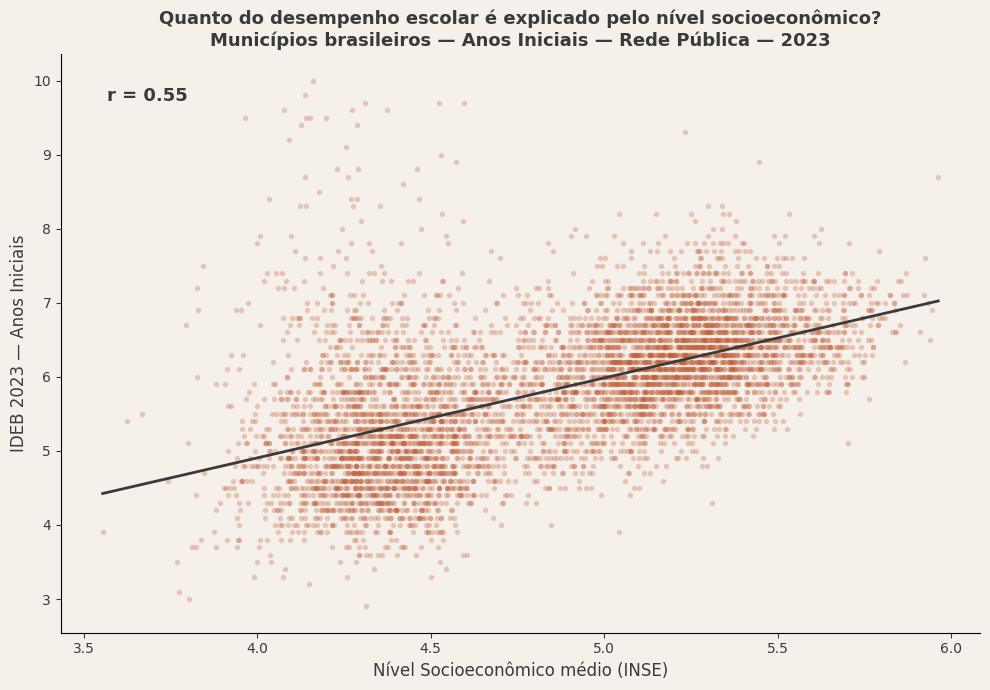

In [39]:
import numpy as np
from scipy import stats
from scipy import stats

# Calcula regressão linear
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_limpo['MEDIA_INSE'], 
    df_limpo['VL_OBSERVADO_2023']
)

# Linha de tendência
x_line = np.linspace(df_limpo['MEDIA_INSE'].min(), df_limpo['MEDIA_INSE'].max(), 100)
y_line = slope * x_line + intercept

# Gráfico
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(COR_CREME)
ax.set_facecolor(COR_CREME)

ax.scatter(
    df_limpo['MEDIA_INSE'], 
    df_limpo['VL_OBSERVADO_2023'],
    color=COR_PRINCIPAL, alpha=0.3, s=15, linewidths=0
)

ax.plot(x_line, y_line, color=COR_GRAFITE, linewidth=2, zorder=5)

ax.text(
    0.05, 0.92,
    f'r = {r_value:.2f}',
    transform=ax.transAxes,
    fontsize=13, color=COR_GRAFITE, fontweight='bold'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Nível Socioeconômico médio (INSE)', fontsize=12)
ax.set_ylabel('IDEB 2023 — Anos Iniciais', fontsize=12)
ax.set_title(
    'Quanto do desempenho escolar é explicado pelo nível socioeconômico?\n'
    'Municípios brasileiros — Anos Iniciais — Rede Pública — 2023',
    fontsize=13, fontweight='bold', color=COR_GRAFITE
)

plt.tight_layout()
plt.savefig('scatter_ideb_inse.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Calcula IDEB esperado e resíduo para cada município
df_limpo['IDEB_ESPERADO'] = slope * df_limpo['MEDIA_INSE'] + intercept
df_limpo['RESIDUO'] = df_limpo['VL_OBSERVADO_2023'] - df_limpo['IDEB_ESPERADO']

# Confere
print(df_limpo[['NO_MUNICIPIO', 'SG_UF', 'MEDIA_INSE', 'VL_OBSERVADO_2023', 'IDEB_ESPERADO', 'RESIDUO']].head(10))
print("\nResíduo médio:", df_limpo['RESIDUO'].mean().round(4))
print("Desvio padrão do resíduo:", df_limpo['RESIDUO'].std().round(4))

            NO_MUNICIPIO SG_UF  MEDIA_INSE  VL_OBSERVADO_2023  IDEB_ESPERADO  \
0  Alta Floresta D'Oeste    RO      4.9904                5.3       5.974061   
1              Ariquemes    RO      4.9264                5.4       5.904977   
2                 Cabixi    RO      4.9473                5.8       5.927538   
3                 Cacoal    RO      5.0131                5.7       5.998565   
4             Cerejeiras    RO      5.0786                5.8       6.069268   
5      Colorado do Oeste    RO      5.0888                6.6       6.080278   
6             Corumbiara    RO      4.9131                5.8       5.890621   
7          Costa Marques    RO      4.7151                4.4       5.676892   
8        Espigão D'Oeste    RO      4.8672                6.0       5.841074   
9          Guajará-Mirim    RO      4.8560                4.9       5.828985   

    RESIDUO  
0 -0.674061  
1 -0.504977  
2 -0.127538  
3 -0.298565  
4 -0.269268  
5  0.519722  
6 -0.090621  
7 -1.27

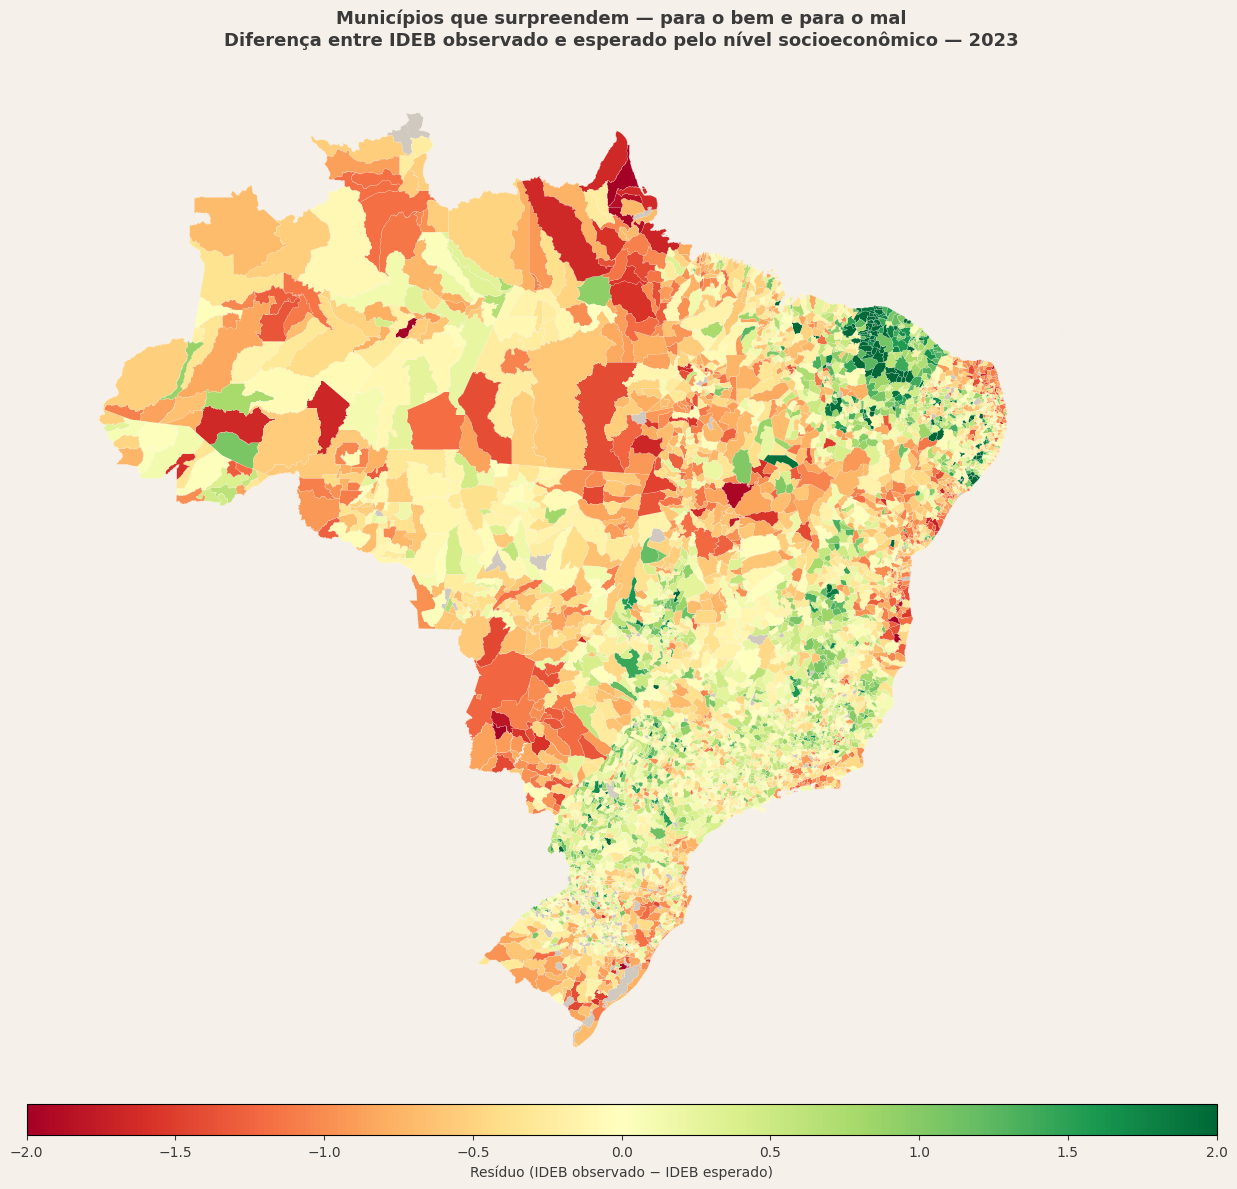

In [41]:
# Merge resíduos com shapefile
gdf_residuo = gdf.merge(
    df_limpo[['CD_MUN', 'RESIDUO']], on='CD_MUN', how='left'
)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(COR_FUNDO)
ax.set_facecolor(COR_FUNDO)

gdf_residuo[gdf_residuo['RESIDUO'].isna()].plot(
    ax=ax, color=COR_SEM_DADO, linewidth=0.1
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1)

gdf_residuo[gdf_residuo['RESIDUO'].notna()].plot(
    column='RESIDUO',
    ax=ax,
    cax=cax,
    cmap='RdYlGn',
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    vmin=-2, vmax=2,
    legend_kwds={
        'label': 'Resíduo (IDEB observado − IDEB esperado)',
        'orientation': 'horizontal'
    }
)

ax.set_title(
    'Municípios que surpreendem — para o bem e para o mal\n'
    'Diferença entre IDEB observado e esperado pelo nível socioeconômico — 2023',
    fontsize=13, fontweight='bold', color=COR_GRAFITE, pad=15
)
ax.axis('off')

plt.tight_layout()
plt.savefig('mapa_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Top 10 positivos — municípios que surpreendem pra cima
top_pos = df_limpo.nlargest(10, 'RESIDUO')[
    ['NO_MUNICIPIO', 'SG_UF', 'MEDIA_INSE', 'VL_OBSERVADO_2023', 'IDEB_ESPERADO', 'RESIDUO']
].round(2)

# Top 10 negativos — municípios que decepcionam
top_neg = df_limpo.nsmallest(10, 'RESIDUO')[
    ['NO_MUNICIPIO', 'SG_UF', 'MEDIA_INSE', 'VL_OBSERVADO_2023', 'IDEB_ESPERADO', 'RESIDUO']
].round(2)

print("=== SURPREENDEM POSITIVAMENTE ===")
print(top_pos.to_string(index=False))
print("\n=== ABAIXO DO ESPERADO ===")
print(top_neg.to_string(index=False))

=== SURPREENDEM POSITIVAMENTE ===
      NO_MUNICIPIO SG_UF  MEDIA_INSE  VL_OBSERVADO_2023  IDEB_ESPERADO  RESIDUO
    Pires Ferreira    CE        4.16               10.0           5.08     4.92
 Santana do Mundaú    AL        4.14                9.8           5.05     4.75
            Coreaú    CE        3.97                9.5           4.87     4.63
        Ibateguara    AL        4.08                9.6           4.99     4.61
União dos Palmares    AL        4.31                9.7           5.24     4.46
      Novo Oriente    CE        4.14                9.5           5.06     4.44
      Pedra Branca    CE        4.15                9.5           5.07     4.43
     Independência    CE        4.27                9.6           5.20     4.40
           Mucambo    CE        4.20                9.5           5.12     4.38
          Ararendá    CE        4.13                9.4           5.04     4.36

=== ABAIXO DO ESPERADO ===
    NO_MUNICIPIO SG_UF  MEDIA_INSE  VL_OBSERVADO_2023  IDE

In [43]:
print(df_limpo[df_limpo['NO_MUNICIPIO'].isin(
    ['Pires Ferreira', 'Santana do Mundaú', 'Coreaú', 'Manaquiri', 'Itapebi', 'Bodoquena']
)][['NO_MUNICIPIO', 'SG_UF', 'QTD_ALUNOS_INSE', 'VL_OBSERVADO_2023', 'RESIDUO']].to_string(index=False))

     NO_MUNICIPIO SG_UF  QTD_ALUNOS_INSE  VL_OBSERVADO_2023   RESIDUO
        Manaquiri    AM              594                2.9 -2.342957
           Coreaú    CE              703                9.5  4.631932
   Pires Ferreira    CE              336               10.0  4.919822
Santana do Mundaú    AL              252                9.8  4.746268
          Itapebi    BA              226                3.3 -2.144705
        Bodoquena    MS              256                3.9 -2.130516


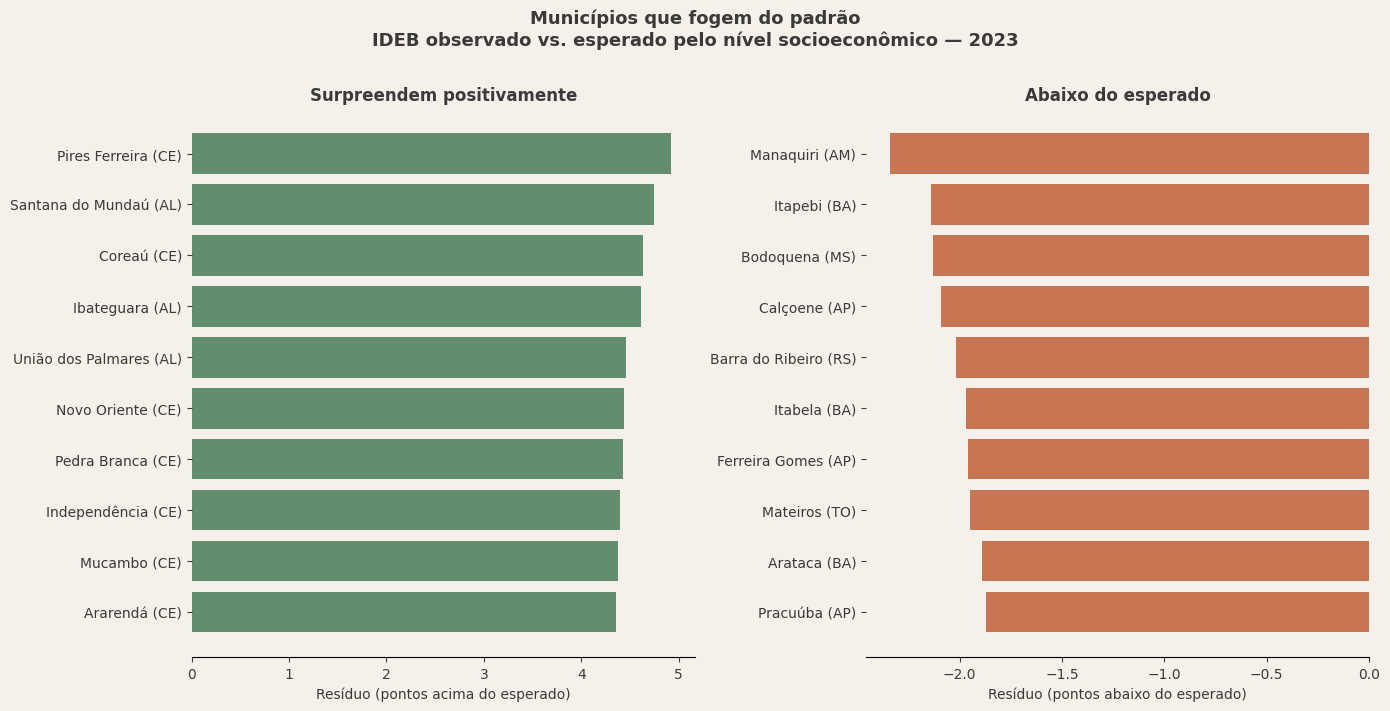

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor(COR_CREME)

# Labels
top_pos['LABEL'] = top_pos['NO_MUNICIPIO'] + ' (' + top_pos['SG_UF'] + ')'
top_neg['LABEL'] = top_neg['NO_MUNICIPIO'] + ' (' + top_neg['SG_UF'] + ')'

# --- Positivos ---
ax1.set_facecolor(COR_CREME)
bars1 = ax1.barh(
    top_pos['LABEL'], top_pos['RESIDUO'],
    color='#4A7C59', alpha=0.85
)
ax1.set_xlabel('Resíduo (pontos acima do esperado)', fontsize=10, color=COR_GRAFITE)
ax1.set_title('Surpreendem positivamente', fontsize=12, fontweight='bold', color=COR_GRAFITE)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.tick_params(colors=COR_GRAFITE)
ax1.invert_yaxis()

# --- Negativos ---
ax2.set_facecolor(COR_CREME)
bars2 = ax2.barh(
    top_neg['LABEL'], top_neg['RESIDUO'],
    color='#C0603A', alpha=0.85
)
ax2.set_xlabel('Resíduo (pontos abaixo do esperado)', fontsize=10, color=COR_GRAFITE)
ax2.set_title('Abaixo do esperado', fontsize=12, fontweight='bold', color=COR_GRAFITE)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(colors=COR_GRAFITE)
ax2.invert_yaxis()

fig.suptitle(
    'Municípios que fogem do padrão\nIDEB observado vs. esperado pelo nível socioeconômico — 2023',
    fontsize=13, fontweight='bold', color=COR_GRAFITE, y=1.01
)

plt.tight_layout()
plt.savefig('barras_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Adiciona região via merge com o shapefile que já tem essa info
df_limpo = df_limpo.merge(
    gdf[['CD_MUN', 'NM_REGIA', 'SIGLA_RG']],
    on='CD_MUN', how='left'
)

print(df_limpo['NM_REGIA'].value_counts())

NM_REGIA
Nordeste        1771
Sudeste         1642
Sul             1101
Centro-oeste     460
Norte            442
Name: count, dtype: int64


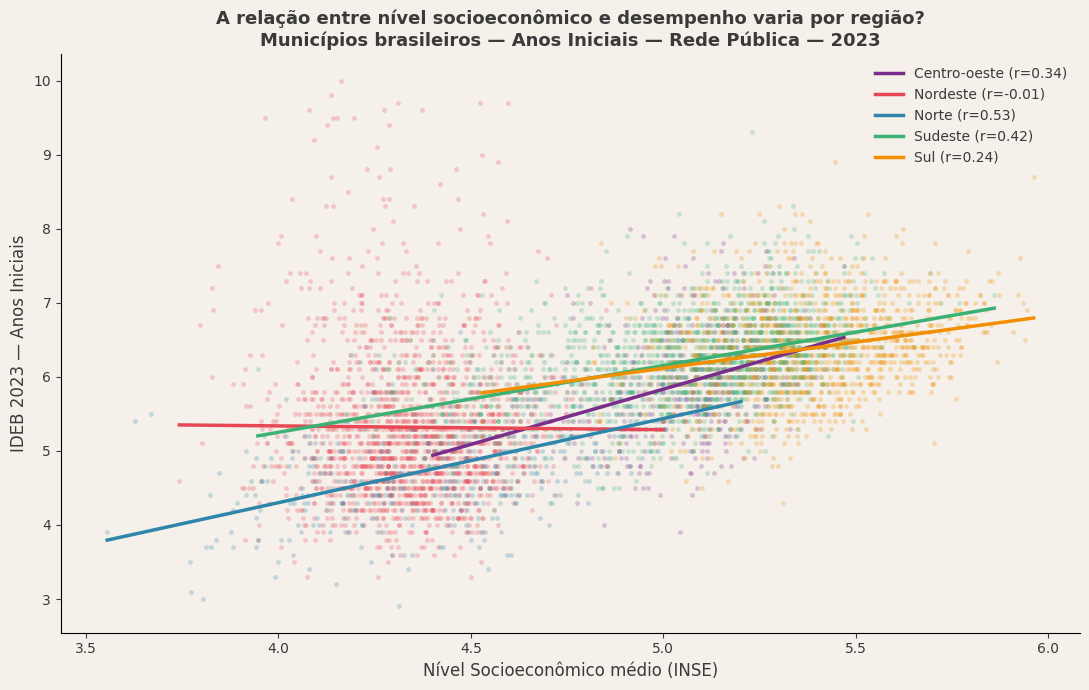

In [46]:
cores_regioes = {
    'Norte': '#2E86AB',
    'Nordeste': '#E84855',
    'Sudeste': '#3BB273',
    'Sul': '#F18F01',
    'Centro-oeste': '#7B2D8B'
}

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(COR_CREME)
ax.set_facecolor(COR_CREME)

for regiao, grupo in df_limpo.groupby('NM_REGIA'):
    cor = cores_regioes[regiao]
    
    # Pontos
    ax.scatter(
        grupo['MEDIA_INSE'],
        grupo['VL_OBSERVADO_2023'],
        color=cor, alpha=0.25, s=12, linewidths=0
    )
    
    # Linha de tendência por região
    s, i, r, p, _ = stats.linregress(grupo['MEDIA_INSE'], grupo['VL_OBSERVADO_2023'])
    x_r = np.linspace(grupo['MEDIA_INSE'].min(), grupo['MEDIA_INSE'].max(), 100)
    ax.plot(x_r, s * x_r + i, color=cor, linewidth=2.5, label=f'{regiao} (r={r:.2f})')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Nível Socioeconômico médio (INSE)', fontsize=12, color=COR_GRAFITE)
ax.set_ylabel('IDEB 2023 — Anos Iniciais', fontsize=12, color=COR_GRAFITE)
ax.set_title(
    'A relação entre nível socioeconômico e desempenho varia por região?\n'
    'Municípios brasileiros — Anos Iniciais — Rede Pública — 2023',
    fontsize=13, fontweight='bold', color=COR_GRAFITE
)
ax.legend(fontsize=10, frameon=False)
ax.tick_params(colors=COR_GRAFITE)

plt.tight_layout()
plt.savefig('scatter_regional.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
import os
arquivos = [
    'mapa_ideb_municipios.png',
    'scatter_ideb_inse.png',
    'mapa_residuos.png',
    'barras_residuos.png',
    'scatter_regional.png'
]

for f in arquivos:
    existe = os.path.exists(f)
    print(f"{'✅' if existe else '❌'} {f}")

✅ mapa_ideb_municipios.png
✅ scatter_ideb_inse.png
✅ mapa_residuos.png
✅ barras_residuos.png
✅ scatter_regional.png


In [48]:
from PIL import Image, ImageDraw, ImageFont
import os

# Cria imagem 64x64
img = Image.new('RGB', (64, 64), color='#C0603A')
draw = ImageDraw.Draw(img)

# Tenta usar uma fonte do sistema, senão usa padrão
try:
    font = ImageFont.truetype('/System/Library/Fonts/Helvetica.ttc', 40)
except:
    font = ImageFont.load_default()

# Centraliza o B
draw.text((16, 8), 'B', fill='white', font=font)

img.save('favicon.png')
print("favicon criado!")

favicon criado!
